## MART_A
Mart A	Wieviel Nettoabsatz haben die Berater im Zeitverlauf akquiriert? Aggregiere auf Berater-Ebene.

In [65]:
import duckdb
from pandas import DataFrame
import matplotlib.pyplot as plt
import pandas as pd

In [66]:

# create a connection to a file called 'file.db'
con = duckdb.connect("../dev.duckdb")
# create a table and load data into it
# con.sql("select * from dev.dev_default_mart.mart_a_nettoabsatz_berater_monatlich").show()
df = (con.table("dev.dev_default_mart.mart_a_nettoabsatz_berater_monatlich"))
df = con.query("select * from dev.dev_default_mart.mart_a_nettoabsatz_berater_monatlich").to_df()
con.close()
# display(df)
# type(df) #pandas.DataFrame
# Note: connections also closed implicitly when they go out of scope

version 01: aggregation only by berater

In [67]:
df2 = df.groupby(['berater']).sum().reset_index()
# df2 = df2[df2["berater"] == 'Bailey, Lilianna']
df2

,berater,monat,sum_nettoabsatz
0,"Allen, Tess",2025-012025-022025-032025-042025-05,296676.11
1,"Bailey, Lilianna",2025-012025-022025-032025-042025-05,33617.68
2,"Baker, Reid",2025-012025-022025-032025-042025-05,59352.66
3,"Brown, Vincent",2025-012025-022025-032025-042025-05,375000.00
4,"Carter, Kelvin",2025-012025-022025-032025-042025-05,1119301.96
5,"Chapman, Alberta",2025-012025-022025-032025-042025-05,2500000.00
6,"Chapman, Arianna",2025-012025-022025-032025-042025-05,29683.70
7,"Craig, Connie",2025-012025-022025-032025-042025-05,199254.91
8,"Crawford, April",2025-012025-022025-032025-042025-05,0.00
9,"Crawford, Victor",2025-012025-022025-032025-042025-05,267252.98


<Axes: xlabel='berater'>

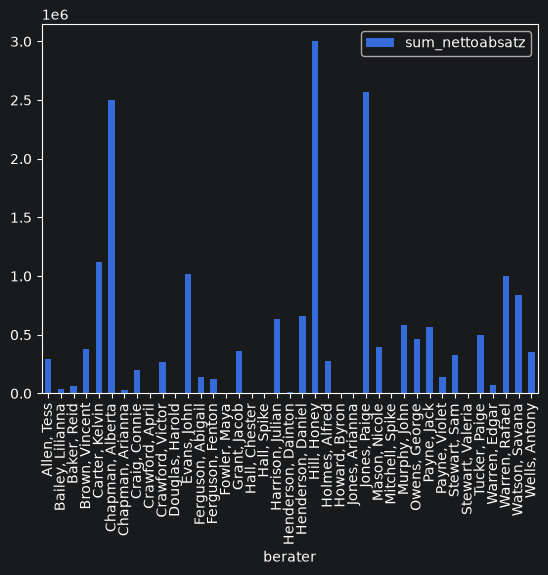

In [68]:

df2.plot.bar(x='berater', y='sum_nettoabsatz')

version 02: aggregation by berater and month

In [69]:
    # df
# df['berater'][0]
# plt.figure();
df3 = df.groupby(['monat','berater']).sum().reset_index()
# df2
# df2.plot.bar(x='monat', rot=0)
pivot_df3 = df3.pivot(index='monat', columns='berater', values='sum_nettoabsatz')
pivot_df3


berater,"Allen, Tess","Bailey, Lilianna","Baker, Reid","Brown, Vincent","Carter, Kelvin","Chapman, Alberta","Chapman, Arianna","Craig, Connie","Crawford, April","Crawford, Victor",...,"Owens, George","Payne, Jack","Payne, Violet","Stewart, Sam","Stewart, Valeria","Tucker, Paige","Warren, Edgar","Warren, Rafael","Watson, Savana","Wells, Antony"
monat,,,,,,,,,,,,,,,,,,,,,
2025-01,296676.11,511.70,59352.66,0.0,623186.91,1500000.0,29683.7,199254.91,0.0,267252.98,...,461539.22,0.00,138941.2,326865.26,0.0,0.0,0.0,649683.29,527682.19,356750.18
2025-02,0.00,8704.00,0.00,250000.0,496115.05,0.0,0.0,0.00,0.0,0.00,...,0.00,566150.40,0.0,0.00,0.0,500000.0,70000.0,29939.30,260193.62,0.00
2025-03,0.00,8948.00,0.00,0.0,0.00,1000000.0,0.0,0.00,0.0,0.00,...,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.00
2025-04,0.00,1751.98,0.00,125000.0,0.00,0.0,0.0,0.00,0.0,0.00,...,0.00,3008.63,0.0,0.00,0.0,0.0,0.0,317876.98,51000.00,0.00
2025-05,0.00,13702.00,0.00,0.0,0.00,0.0,0.0,0.00,0.0,0.00,...,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.00


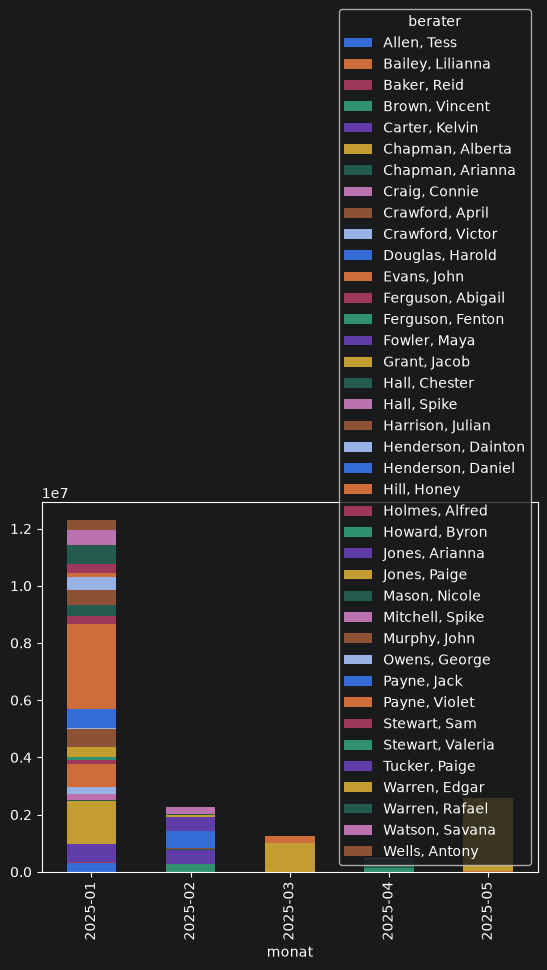

In [70]:
# df4 = pivot_df3.filter(items=['berater','Bailey, Lilianna', 'Brown, Vincent', 'Carter, Kelvin'])
df4 = pivot_df3
# NICE ONES TO USE: 'Bailey, Lilianna'
# SECOND CHOICE:     'Brown, Vincent' 'Carter, Kelvin'
df4.plot.bar(stacked=True, legend=True);
